# Antenna Tilt Optimization — 1a: single-antenna geometry and the RF field

Builds the single-sector RF model step by step, making each assumption explicit and verifying every
quantity against the Ericsson LTE model (Athley & Johansson, 2010; `docs/references/`). The physics
lives in `telecomopt.rf`; this notebook derives, checks, and visualizes it.

Sections: **(1) geometry** — the direction from antenna to a ground point · (2) path loss ·
(3) elevation gain and tilt · (4) path gain → SNR → spectral efficiency · (5) coverage vs tilt.


## Scope and assumptions of this first model

- **Flat ground**, with antenna and receiver heights measured from the same ground level.
- A **fixed antenna** and a **fixed observation point** on the ground (a "location"; user traffic
  and spatial distributions are introduced later, in 1b).
- `d > 0` is the **horizontal** distance, not the slant antenna–point distance.
- We take a **vertical cross-section along the sector's boresight** (forward direction). Azimuth is
  deferred to the full-sector extension.
- This section is **geometry (direction) only** — it makes no assumption about whether the path is
  obstructed. The path-loss and antenna-pattern expressions added next are **empirical models**, not
  first-principles derivations; the aim is to build the model step by step with its assumptions
  stated.


## 1. Geometry — the depression angle to a ground point

A ground point at horizontal distance $d$ from the tower is seen by the antenna at an angle **below
the horizon**:

$$\beta(d) = \arctan\!\left(\frac{h_{\mathrm{BS}} - h_{\mathrm{UE}}}{d}\right),
\qquad \Delta h = h_{\mathrm{BS}} - h_{\mathrm{UE}} = 30 - 1.5 = 28.5\ \text{m}.$$

**Convention.** $\beta$ is measured **positive downward** (horizon $\to$ ground). Ericsson defines
elevation **positive upward**, so with zero mechanical tilt $\alpha_{\text{Ericsson}} = -\beta$. The
beam is steered by a downtilt $t$ (also positive downward); in this vertical slice the antenna aims
at the ground point whose $\beta$ equals $t$. The library encodes this consistently — its elevation
gain uses $(\beta - t)$ and peaks at $\beta = t$ — so no sign ambiguity propagates into the model.

**Intuition.** A point *close* to the tower has a *large* $\beta$ (steep, looking down); a *far*
point has $\beta \to 0$ (near the horizon). Because the beam has finite width (elevation HPBW
$6.5°$), points within a few degrees of the pointing angle also receive strong gain — an exact match
is the *peak* direction, not the only strong one. In short: **geometry fixes the direction to a
point; tilt fixes where the beam points.**

**Numerical note.** As $d \to 0$ the point is under the mast ($\beta \to 90°$); `elevation_angle_deg`
clamps $d \ge 1$ m to avoid a division by zero.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from telecomopt.rf import RFParams, elevation_angle_deg

p = RFParams()
delta_h = p.bs_height - p.ue_height          # 28.5 m
print(f"h_BS = {p.bs_height} m,  h_UE = {p.ue_height} m,  delta_h = {delta_h} m")


h_BS = 30.0 m,  h_UE = 1.5 m,  delta_h = 28.5 m


In [3]:
def depression_angle_deg(d_m, params=p):
    """Downward angle beta(d) from the antenna to a ground point, in degrees (positive downward)."""
    dh = params.bs_height - params.ue_height
    return np.degrees(np.arctan(dh / np.maximum(d_m, 1.0)))

# Verify our expression against the library across a range of distances.
d_check = np.array([50, 200, 500, 1000], dtype=float)
ours = depression_angle_deg(d_check)
lib = np.array([elevation_angle_deg(d) for d in d_check])

print(f"{'d [m]':>7}{'beta (ours) [deg]':>20}{'beta (library) [deg]':>22}")
for d, a, b in zip(d_check, ours, lib):
    print(f"{d:7.0f}{a:20.2f}{b:22.2f}")
assert np.allclose(ours, lib), "convention mismatch vs telecomopt.rf"
print("\nMatches telecomopt.rf.elevation_angle_deg to floating-point precision.")


  d [m]   beta (ours) [deg]  beta (library) [deg]
     50               29.68                 29.68
    200                8.11                  8.11
    500                3.26                  3.26
   1000                1.63                  1.63

Matches telecomopt.rf.elevation_angle_deg to floating-point precision.


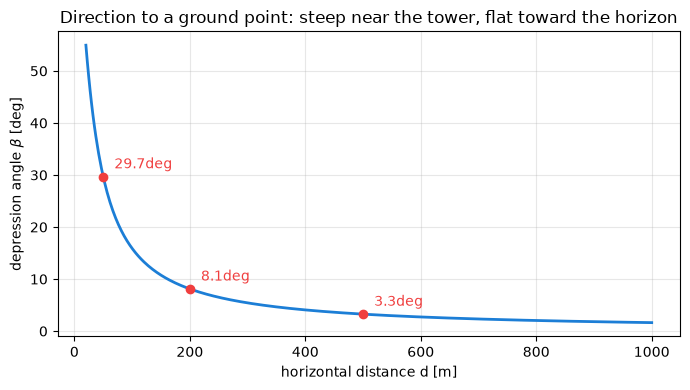

In [4]:
d = np.linspace(20, 1000, 400)
beta = depression_angle_deg(d)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d, beta, color="#1c7ed6", lw=2)
for d0 in (50, 200, 500):
    ax.plot(d0, depression_angle_deg(d0), "o", color="#f03e3e")
    ax.annotate(f"{depression_angle_deg(d0):.1f}deg", (d0, depression_angle_deg(d0)),
                textcoords="offset points", xytext=(8, 6), color="#f03e3e")
ax.set_xlabel("horizontal distance d [m]")
ax.set_ylabel(r"depression angle $\beta$ [deg]")
ax.set_title("Direction to a ground point: steep near the tower, flat toward the horizon")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Reading the curve.** $\beta$ falls off quickly at first and then flattens: for large $d$,
$\arctan(\Delta h / d) \approx \Delta h / d \to 0$, so beyond a few hundred metres every point sits
within a narrow band close to the horizon. That is why a single fixed downtilt can serve a wide
range of far distances but is very selective about near ones — the geometry we will feed into the
elevation pattern next.
